### Bước 1: Khai báo thư viện và Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

# Tải dataset Titanic từ seaborn
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Bước 2: Phân tích dữ liệu (EDA)

### loại bỏ một vài cột thừa

In [2]:
for c in df.columns:
    print(f"percentage of miss sing value for {c} is {(df[c].isnull().mean() * 100):.2f}%")

leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']    # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

percentage of miss sing value for survived is 0.00%
percentage of miss sing value for pclass is 0.00%
percentage of miss sing value for sex is 0.00%
percentage of miss sing value for age is 19.87%
percentage of miss sing value for sibsp is 0.00%
percentage of miss sing value for parch is 0.00%
percentage of miss sing value for fare is 0.00%
percentage of miss sing value for embarked is 0.22%
percentage of miss sing value for class is 0.00%
percentage of miss sing value for who is 0.00%
percentage of miss sing value for adult_male is 0.00%
percentage of miss sing value for deck is 77.22%
percentage of miss sing value for embark_town is 0.22%
percentage of miss sing value for alive is 0.00%
percentage of miss sing value for alone is 0.00%


### quan sát tổng quan:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


### Vẽ vài biểu đồ để quan sát:

/tmp/ipykernel_145473/2542250187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='viridis')


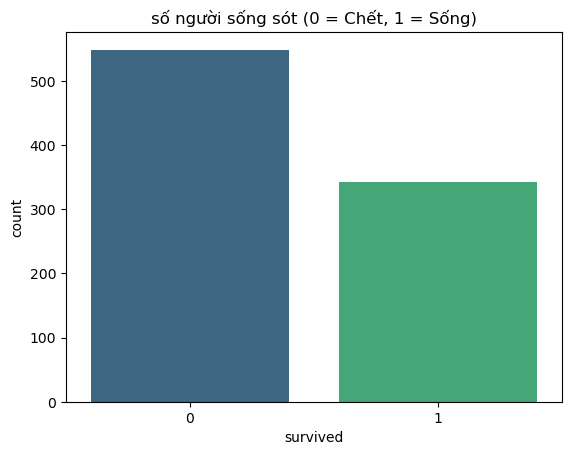

/tmp/ipykernel_145473/2542250187.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_145473/2542250187.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sibsp', y='survived', data=df, ax=axes[1], palette='muted')
/tmp/ipykernel_145473/2542250187.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parch', y='survived', data=df, ax=axes[2], palette='magma')


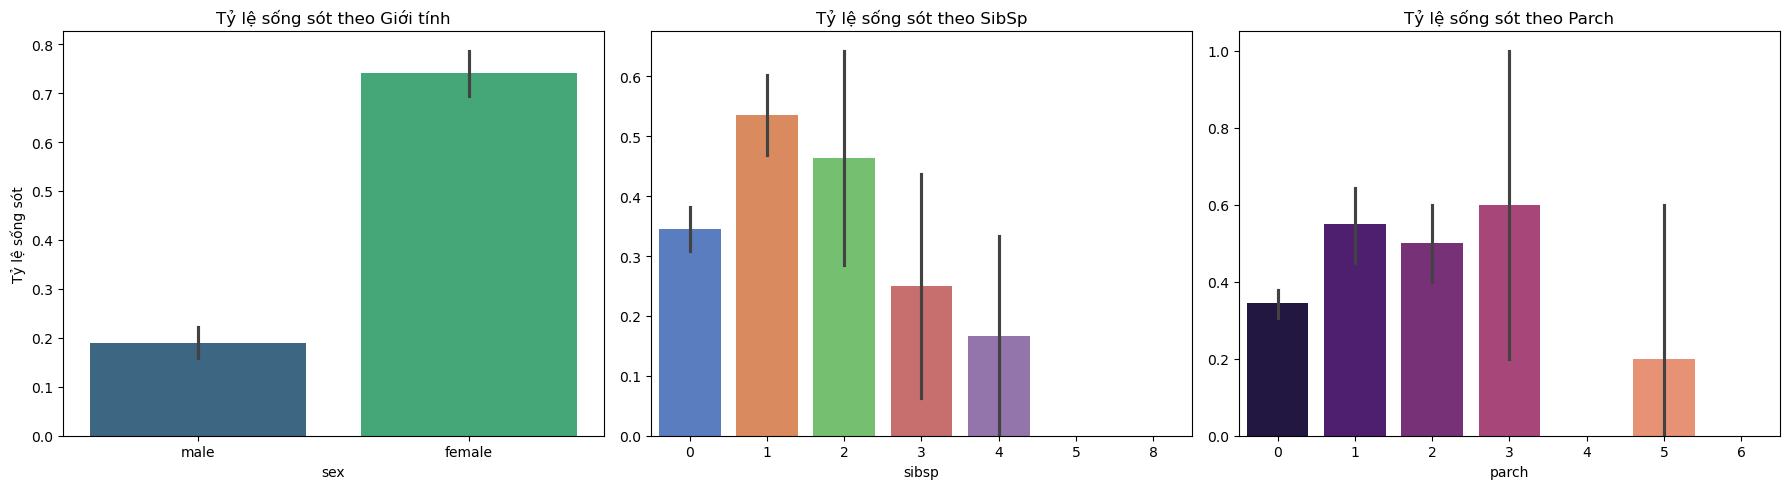

In [4]:
# 2. Trực quan hóa tỷ lệ sống sót
sns.countplot(x='survived', data=df, palette='viridis')
plt.title('số người sống sót (0 = Chết, 1 = Sống)')
plt.show()

# Thiết lập kích thước tổng thể cho hàng biểu đồ (rộng 18 inch, cao 5 inch)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Biểu đồ tỷ lệ sống sót theo Giới tính (Sex)
sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Tỷ lệ sống sót theo Giới tính')
axes[0].set_ylabel('Tỷ lệ sống sót')

# 2. Biểu đồ tỷ lệ sống sót theo Số anh chị em/vợ chồng đi cùng (SibSp)
sns.barplot(x='sibsp', y='survived', data=df, ax=axes[1], palette='muted')
axes[1].set_title('Tỷ lệ sống sót theo SibSp')
axes[1].set_ylabel('') # Ẩn nhãn y để tránh lặp lại

# 3. Biểu đồ tỷ lệ sống sót theo Số cha mẹ/con cái đi cùng (Parch)
sns.barplot(x='parch', y='survived', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Tỷ lệ sống sót theo Parch')
axes[2].set_ylabel('') # Ẩn nhãn y để tránh lặp lại

# Tự động điều chỉnh khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()
plt.show()

Mặc dù cột màu tím (parch = 3) cao hơn hẳn các cột khác, nhưng vạch đen của nó quá dài. Điều này cảnh báo chúng ta rằng: "Đừng quá tin vào con số này, vì có thể chỉ có vài người thuộc nhóm này nên tỉ lệ sống sót bị vọt lên cao ngẫu nhiên thôi".

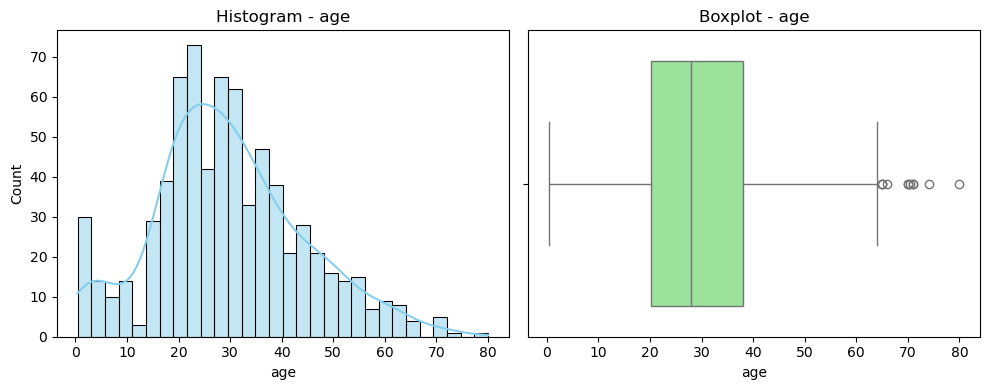

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['age'].dropna(), bins=30, color='skyblue', kde=True, ax=axes[0])
axes[0].set_title('Histogram - age')
axes[0].set_xlabel('age')

sns.boxplot(x=df['age'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot - age')
axes[1].set_xlabel('age')

plt.tight_layout()
plt.show()

phân phối vẫn khá lệch phải, nên fill bằng median.

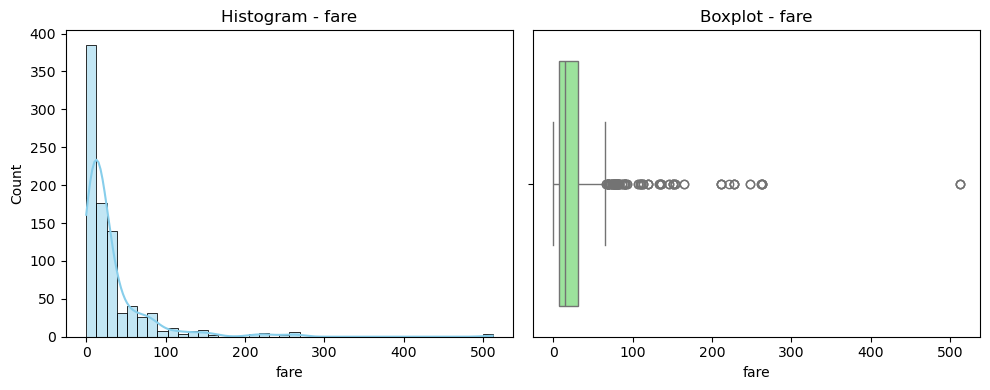

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df['fare'].dropna(), bins=40, color='skyblue', kde=True, ax=axes[0])
axes[0].set_title('Histogram - fare')
axes[0].set_xlabel('fare')

sns.boxplot(x=df['fare'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot - fare')
axes[1].set_xlabel('fare')

plt.tight_layout()
plt.show()

phân phối chuẩn lệch phải do có vài giá trị rất nhỏ, có thể fill na bằng median 

### IQR


In [7]:
def dem_outlier_iqr(s):
    s = s.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((s < lower) | (s > upper)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return (z > nguong).sum()

for col in ["age", "fare"]:
    print(col, "IQR:", dem_outlier_iqr(df[col]), "Zscore:", dem_outlier_zscore(df[col]))

age IQR: 11 Zscore: 2
fare IQR: 116 Zscore: 20


### Chia tập: 

In [8]:
X = df.drop(columns="survived")
y = df["survived"]

# 70 / 15 / 15, stratify để giữ tỷ lệ hai lớp
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  tỷ lệ survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
  tỷ lệ survived (train): 0.384
  tỷ lệ survived (val): 0.388
  tỷ lệ survived (test): 0.381


### pipeline for data:

In [9]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy= 'median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
]) 

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

df["embarked"].nunique()

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


### model create:

In [10]:
# 1. Khởi tạo 2 mô hình
log_reg = LogisticRegression(random_state=42)
lin_reg = LinearRegression()

# Huấn luyện mô hình Logistic Regression
log_reg.fit(X_train_t, y_train)

# Huấn luyện mô hình Linear Regression
lin_reg.fit(X_train_t, y_train)

# Dự đoán với Logistic Regression (mô hình tự hiểu trả về 0 hoặc 1)
y_pred_log = log_reg.predict(Xte)

# Dự đoán với Linear Regression
y_pred_lin_continuous = lin_reg.predict(Xte)
# Ép kiểu dự đoán của Linear Regression về 0 hoặc 1 dựa trên ngưỡng 0.5
y_pred_lin = [1 if val >= 0.5 else 0 for val in y_pred_lin_continuous]

========== Logistic Regression ==========
Accuracy  : 0.7836
Precision : 0.7500
Recall    : 0.6471
F1-score  : 0.6947



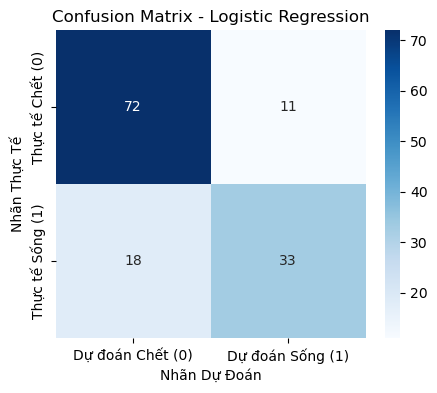

========== Linear Regression ==========
Accuracy  : 0.7612
Precision : 0.7021
Recall    : 0.6471
F1-score  : 0.6735



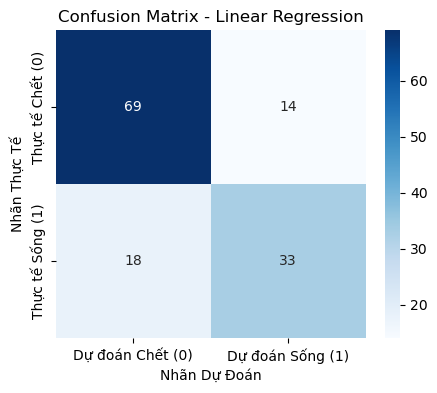

In [11]:
def evaluate_and_plot(y_true, y_pred, model_name):
    # Tính toán các metric
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # In kết quả
    print(f"========== {model_name} ==========")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {pre:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("========================================\n")
    
    # Tính Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Trực quan hóa Confusion Matrix bằng seaborn
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Dự đoán Chết (0)', 'Dự đoán Sống (1)'],
                yticklabels=['Thực tế Chết (0)', 'Thực tế Sống (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Nhãn Thực Tế')
    plt.xlabel('Nhãn Dự Đoán')
    plt.show()

# Đánh giá mô hình Logistic Regression
evaluate_and_plot(y_test, y_pred_log, "Logistic Regression")

# Đánh giá mô hình Linear Regression
evaluate_and_plot(y_test, y_pred_lin, "Linear Regression")

Mặc dù Linear Regression có thể "chữa cháy" để dùng cho bài toán phân loại, nhưng nó vi phạm các giả định thống kê cốt lõi. Vì vậy, đối với bất kỳ bài toán phân loại xem một sự kiện "Có" hay "Không" xảy ra (Sống hay Chết, Mắc bệnh hay Không mắc bệnh, Churn hay không Churn), chúng ta luôn luôn ưu tiên sử dụng Logistic Regression thay vì Linear Regression.

# Bài 2: Dry beans

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('Dry_Bean_Dataset/dry_bean_train.csv')
test_df = pd.read_csv('Dry_Bean_Dataset/dry_bean_test.csv')
train_df.head()



,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


In [13]:
X_train = train_df.drop(columns=['class'])
y_train = train_df['class']
X_test = test_df.drop(columns=['class'])
y_test = test_df['class']

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### logistic regression:

In [14]:
log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train_enc)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test_enc, y_pred_lr))
print(classification_report(y_test_enc, y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.9191583610188261
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



/home/trieu_kernel/miniconda3/envs/mliot_week01/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### KNN

In [15]:
# Tìm k tối ưu bằng cách thử nhiều giá trị
accuracies = []
k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_enc)
    pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test_enc, pred))

best_k = k_range[np.argmax(accuracies)]
print(f"Best k = {best_k}, accuracy = {max(accuracies):.4f}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train_enc)
y_pred_knn = knn_final.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test_enc, y_pred_knn))
print(classification_report(y_test_enc, y_pred_knn, target_names=le.classes_))

Best k = 20, accuracy = 0.9181
KNN Accuracy: 0.9180509413067552
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.96      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



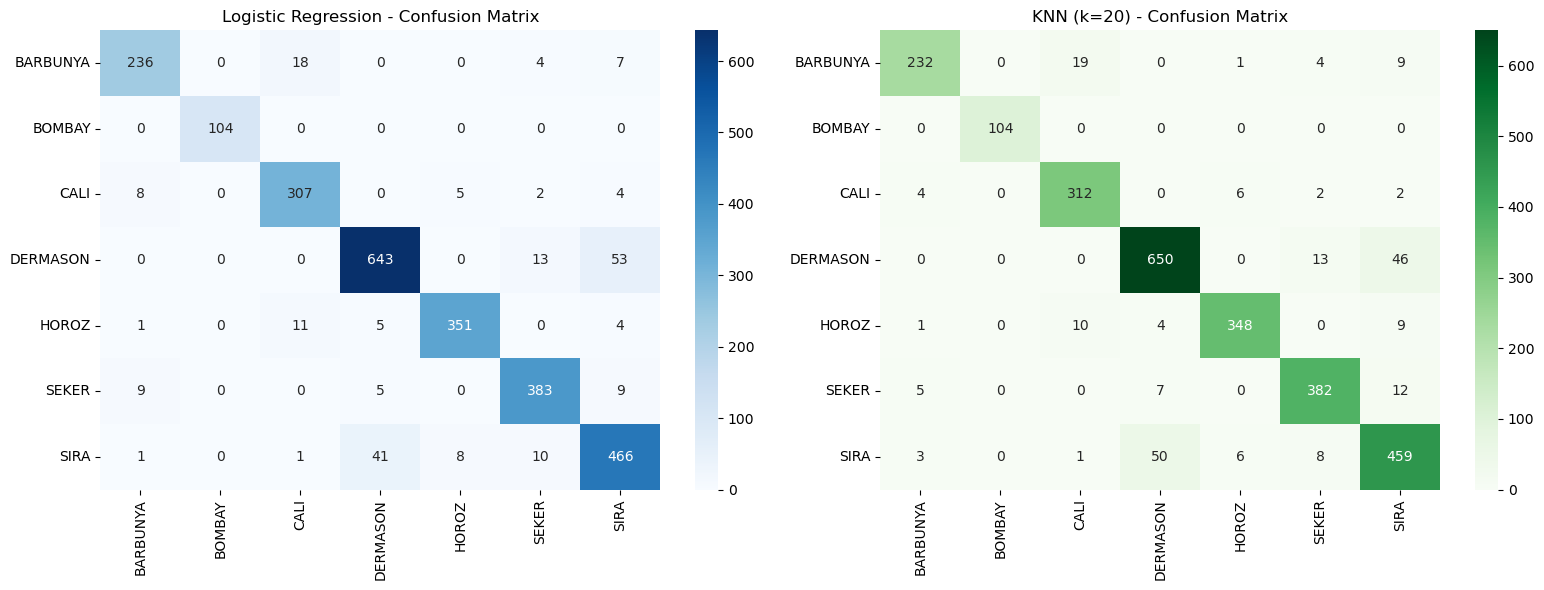

In [16]:
cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
cm_knn = confusion_matrix(y_test_enc, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression - Confusion Matrix')
sns.heatmap(cm_knn, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1], cmap='Greens')
axes[1].set_title(f'KNN (k={best_k}) - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)